In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 5, 1, 9, 45)) & (dataset.data.index < datetime.datetime(2024, 5, 30)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [4]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
ga1 = systemClasses.System(dataset=dataset, name="GA-1")
ga2 = systemClasses.System(dataset=dataset, name="GA-2")

Initializing GA-2 Sensors: 100%|██████████| 18/18 [00:01<00:00, 11.54sensor/s]


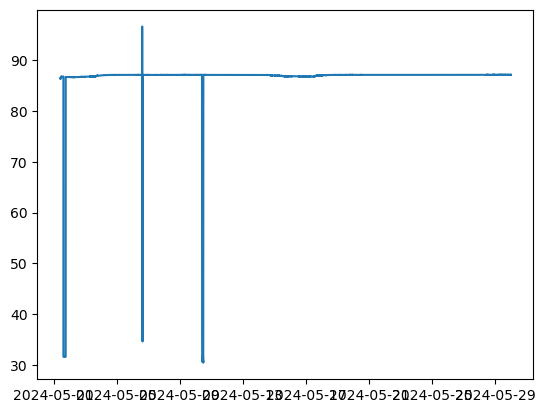

In [5]:
plt.plot(ga2.sensors[48848].muxEqualization().data)

In [6]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
ga1.calibrate(calibName="LN2023_GA_PM_PP")
ga2.calibrate(calibName="LN2023_GA_PM_PP")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:06<00:00,  7.51sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 81.21sensor/s]
Equalizing GA-1 Sensors: 100%|██████████| 18/18 [00:01<00:00, 10.14sensor/s]
Calibrating GA-1 Sensors - Calibration Name: LN2023_GA_PM_PP: 100%|██████████| 18/18 [00:00<00:00, 94.89sensor/s]


ERROR: SensorID (1) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (2) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (3) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (4) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (5) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (6) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (7) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (8) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (9) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (10) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (11) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (12) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (13) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (14) not found in calibration (LN2023_GA_PM_PP)


Equalizing GA-2 Sensors: 100%|██████████| 18/18 [00:01<00:00, 10.36sensor/s]
Calibrating GA-2 Sensors - Calibration Name: LN2023_GA_PM_PP: 100%|██████████| 18/18 [00:00<00:00, 52.76sensor/s]

ERROR: SensorID (15) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (16) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (17) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (18) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (19) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (20) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (21) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (22) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (23) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (24) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (25) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (26) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (27) not found in calibration (LN2023_GA_PM_PP)
ERROR: SensorID (28) not found in calibration (LN2023_GA_PM_PP)


In [7]:
cryo = systemClasses.System(dataset=dataset, name="CRYO")

Initializing CRYO Sensors: 100%|██████████| 16/16 [00:01<00:00, 14.78sensor/s]


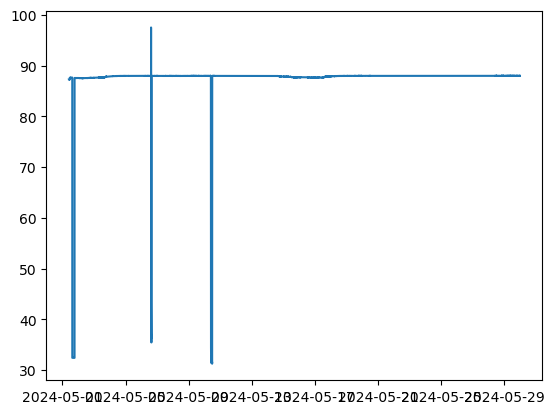

In [8]:
plt.plot(ga2.sensors[48848].data)

No handles with labels found to put in legend.


Text(0.5, 1.0, 'Ullage Temperature (Gas phase)')

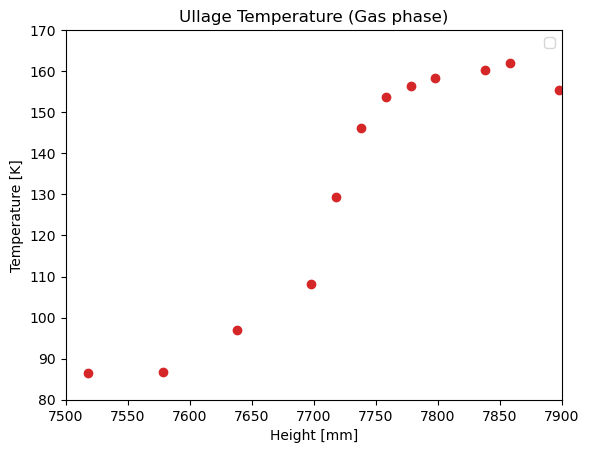

In [21]:
ga1.makeProfiles(tini=datetime.datetime(2024, 5, 15, 10), tend=datetime.datetime(2024, 5, 15, 10, 30, 0))
ga2.makeProfiles(tini=datetime.datetime(2024, 5, 15, 10), tend=datetime.datetime(2024, 5, 15, 10, 30, 0))
tgrad.makeProfiles(tini=datetime.datetime(2024, 5, 15, 10), tend=datetime.datetime(2024, 5, 15, 10, 30, 0))
#plt.errorbar(ga1.profiles["Y"].values, ga1.profiles["temp"].values, yerr=ga1.profiles["err"].values, fmt='o', label="LOWER CE ON", color="tab:blue")
plt.errorbar(ga2.profiles["Y"].values, ga2.profiles["temp"].values, yerr=ga2.profiles["err"].values, fmt='o', color="tab:red")
# plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="TGRAD", color="tab:orange")
# plt.axvline(1e2*cryo.sensors[1041].data.mean())
plt.ylim(80, 170)
plt.xlim(7500, 7900)
plt.legend();
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")
plt.title("Ullage Temperature (Gas phase)")

In [23]:
print(cryo.sensors[1041].data)

2024-05-01 09:46:00    76.498375
2024-05-01 09:47:00    76.498375
2024-05-01 09:48:00    76.498375
2024-05-01 09:49:00    76.498375
2024-05-01 09:50:00    76.498375
                         ...    
2024-05-01 10:50:00    75.747360
2024-05-01 10:51:00    75.747360
2024-05-01 10:52:00    75.747360
2024-05-01 10:53:00    75.747360
2024-05-01 10:54:00    75.747360
Length: 69, dtype: float64
